
# K-Means Demo, Exercises, and Solutions

This notebook teaches the **k-means clustering** algorithm through small demos, exercises, and visualizations.

## What you will learn
- the k-means objective
- how Lloyd's algorithm updates assignments and centroids
- how to choose the number of clusters \(K\) using **inertia** and **silhouette score**
- where k-means works well, and where it struggles
- one practical application: **image color quantization**

## Mathematical core

Given data points \(x_1,\dots,x_n \in \mathbb{R}^d\), k-means looks for:
- cluster assignments \(z_i \in \{1,\dots,K\}\)
- cluster centroids \(\mu_1,\dots,\mu_K \in \mathbb{R}^d\)

that minimize the **within-cluster sum of squares**
\[
J(\{z_i\}, \{\mu_k\}) = \sum_{i=1}^n \left\|x_i - \mu_{z_i}\right\|_2^2.
\]

Lloyd's algorithm alternates between:

1. **Assignment step**
\[
z_i \leftarrow \arg\min_{k} \|x_i-\mu_k\|_2^2
\]

2. **Update step**
\[
\mu_k \leftarrow \frac{1}{|C_k|}\sum_{i:z_i=k} x_i
\]

---

## Sources that inspired the examples

These exercises borrow ideas from the official **scikit-learn** examples and documentation:

- K-means user guide
- Demonstration of k-means assumptions
- Silhouette analysis for choosing \(K\)
- Color quantization using k-means

A references section with links appears at the end.


In [3]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons, load_sample_image
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

np.random.seed(7)
plt.rcParams["figure.figsize"] = (6, 5)

def plot_clusters(X, labels=None, centers=None, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], s=20)
    else:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=20)
    if centers is not None:
        ax.scatter(
            centers[:, 0], centers[:, 1],
            s=250, marker="X", edgecolor="black", linewidth=1.5
        )
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    return ax

def assign_points(X, centers):
    dists = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    return np.argmin(dists, axis=1)

def update_centers(X, labels, K):
    return np.vstack([X[labels == k].mean(axis=0) for k in range(K)])

def lloyd_trace(X, centers_init, n_steps=5):
    centers = centers_init.copy().astype(float)
    history = []
    for step in range(n_steps):
        labels = assign_points(X, centers)
        inertia = ((X - centers[labels]) ** 2).sum()
        history.append((step, centers.copy(), labels.copy(), inertia))
        new_centers = update_centers(X, labels, centers.shape[0])
        if np.allclose(new_centers, centers):
            centers = new_centers
            history.append((step + 1, centers.copy(), labels.copy(), inertia))
            break
        centers = new_centers
    labels = assign_points(X, centers)
    inertia = ((X - centers[labels]) ** 2).sum()
    history.append(("final", centers.copy(), labels.copy(), inertia))
    return history

print("Setup complete.")


Setup complete.



## 1. Demo: k-means on well-separated blobs

This is k-means in its comfort zone: compact, roughly spherical clusters.


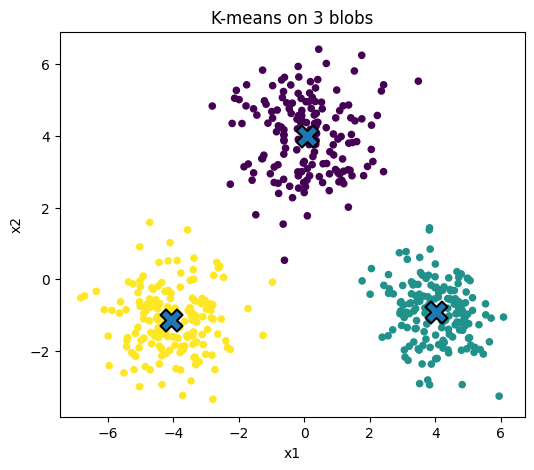

Inertia: 909.12


In [4]:

X_blobs, y_blobs = make_blobs(
    n_samples=500,
    centers=[(-4, -1), (0, 4), (4, -1)],
    cluster_std=[0.9, 1.1, 0.8],
    random_state=12
)

kmeans3 = KMeans(n_clusters=3, init="k-means++", n_init=20, random_state=12)
labels3 = kmeans3.fit_predict(X_blobs)
centers3 = kmeans3.cluster_centers_

fig, ax = plt.subplots()
plot_clusters(X_blobs, labels3, centers3, title="K-means on 3 blobs", ax=ax)
plt.show()

print("Inertia:", round(kmeans3.inertia_, 2))



## 2. Exercise 1: one round of Lloyd's algorithm by hand

We start with a tiny 2D dataset and an intentionally rough set of initial centroids.

### Your task
1. assign each point to its nearest centroid
2. recompute the centroids as cluster means
3. compare your result with `sklearn.cluster.KMeans`

This exercise makes the mechanics of k-means feel less like magic and more like plumbing.


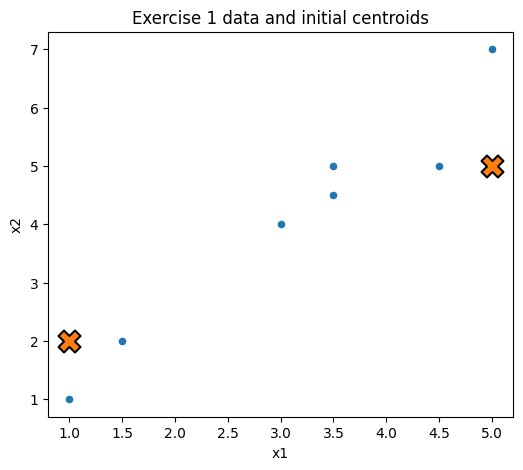

Initial centroids:
[[1. 2.]
 [5. 5.]]


In [5]:

X_small = np.array([
    [1.0, 1.0], [1.5, 2.0], [3.0, 4.0], [5.0, 7.0],
    [3.5, 5.0], [4.5, 5.0], [3.5, 4.5]
])

centers0 = np.array([
    [1.0, 2.0],
    [5.0, 5.0]
])

fig, ax = plt.subplots()
plot_clusters(X_small, centers=centers0, title="Exercise 1 data and initial centroids", ax=ax)
plt.show()

print("Initial centroids:")
print(centers0)



Labels after assignment step:
[0 0 1 1 1 1 1]

Updated centroids:
[[1.25 1.5 ]
 [3.9  5.1 ]]


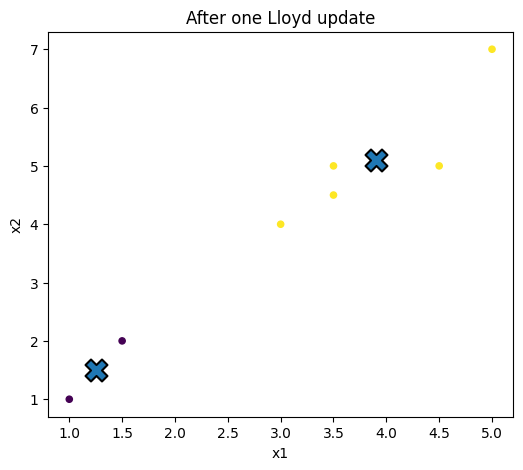

In [6]:

# TODO:
# 1) assign each point in X_small to the nearest centroid in centers0
# 2) compute the updated centroids
# 3) print labels and new_centers
dists = ((X_small[:, None, :] - centers0[None, :, :]) ** 2).sum(axis=2)
labels = np.argmin(dists, axis=1)

new_centers = np.vstack([
    X_small[labels == k].mean(axis=0)
    for k in range(centers0.shape[0])
])

print("\nLabels after assignment step:")
print(labels)
print("\nUpdated centroids:")
print(new_centers)

fig, ax = plt.subplots()
plot_clusters(X_small, labels, new_centers, title="After one Lloyd update", ax=ax)
plt.show()

# labels = ...
# new_centers = ...
# print(labels)
# print(new_centers)



### Check against scikit-learn


In [7]:

km_small = KMeans(n_clusters=2, init=centers0, n_init=1, max_iter=1, random_state=0)
labels_sklearn = km_small.fit_predict(X_small)

print("scikit-learn labels after one update-compatible run:")
print(labels_sklearn)
print("\nscikit-learn centers:")
print(km_small.cluster_centers_)


scikit-learn labels after one update-compatible run:
[0 0 1 1 1 1 1]

scikit-learn centers:
[[1.25 1.5 ]
 [3.9  5.1 ]]



## 3. Exercise 2: choosing the number of clusters \(K\)

Two popular diagnostics are:

- **Inertia**: always decreases as \(K\) increases, so you look for an elbow
- **Silhouette score**: a point-wise separation score, averaged over samples

The scikit-learn docs use silhouette analysis as a practical way to compare candidate values of \(K\).


In [8]:

# TODO:
# For K in 2, 3, 4, 5, 6:
rows = []

for K in range(2, 7):
    km = KMeans(n_clusters=K, init="k-means++", n_init=20, random_state=12)
    labels = km.fit_predict(X_blobs)
    rows.append({
        "K": K,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_blobs, labels),
    })

metrics_df = pd.DataFrame(rows)
metrics_df
#   1) fit KMeans on X_blobs
#   2) store inertia
#   3) store silhouette_score
# Then make a DataFrame called metrics_df with columns:
#   K, inertia, silhouette


,K,inertia,silhouette
0,2,4179.765754,0.551437
1,3,909.124624,0.726803
2,4,778.549313,0.598160
3,5,672.604241,0.460786
4,6,580.367993,0.340062


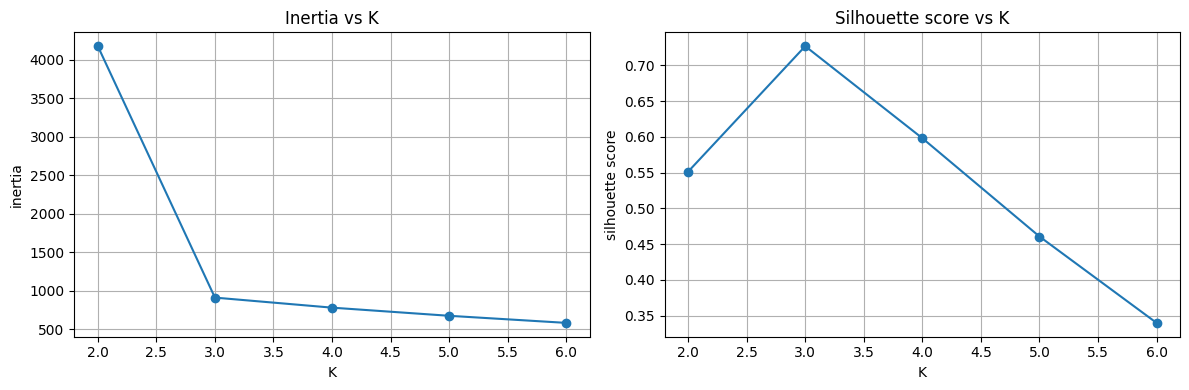

In [10]:

# TODO:
# Make two plots:
#   1) inertia vs K
#   2) silhouette vs K
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(metrics_df["K"], metrics_df["inertia"], marker="o")
axes[0].set_title("Inertia vs K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("inertia")
axes[0].grid(True)

axes[1].plot(metrics_df["K"], metrics_df["silhouette"], marker="o")
axes[1].set_title("Silhouette score vs K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("silhouette score")
axes[1].grid(True)

plt.tight_layout()
plt.show()
# Which K would you choose? The best is K=3



## 4. Exercise 3: where k-means struggles

The official scikit-learn example on k-means assumptions shows a key caveat:

k-means is happiest with **convex, isotropic** clusters. It can behave badly on elongated shapes, unequal variances, or non-convex structures.

We will test it on the classic **two moons** dataset.


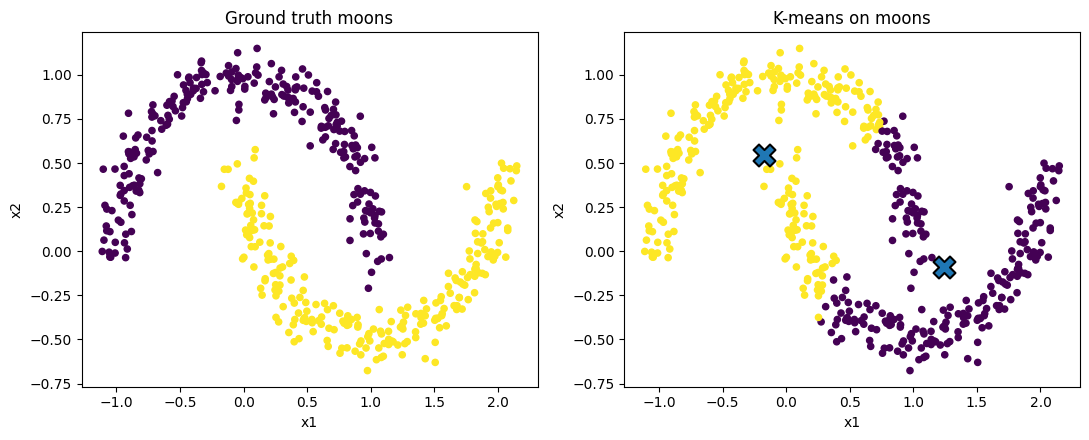

Silhouette score on moons: 0.482


In [11]:

X_moons, y_moons = make_moons(n_samples=500, noise=0.08, random_state=7)

km_moons = KMeans(n_clusters=2, init="k-means++", n_init=20, random_state=7)
labels_moons = km_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_clusters(X_moons, y_moons, title="Ground truth moons", ax=axes[0])
plot_clusters(X_moons, labels_moons, km_moons.cluster_centers_, title="K-means on moons", ax=axes[1])
plt.tight_layout()
plt.show()

print("Silhouette score on moons:", round(silhouette_score(X_moons, labels_moons), 3))


In [ ]:

# TODO:
# Write 2-4 sentences:
# Why does k-means fail on the moons dataset?
# Answer in terms of the geometry of the clusters and the centroid-based objective.


K-means struggles with the two moons dataset because the clusters are not round. They have curved moon-like shapes.

K-means only looks for groups around center points, so it cannot follow curved shapes well. As a result, it splits the moons in the wrong way.



## 5. Bonus demo: image color quantization

A practical use of k-means is to compress the color palette of an image.

Each pixel is a point in \(\mathbb{R}^3\) using its RGB values.  
K-means finds a small codebook of representative colors, and each pixel is replaced by its nearest codebook color.


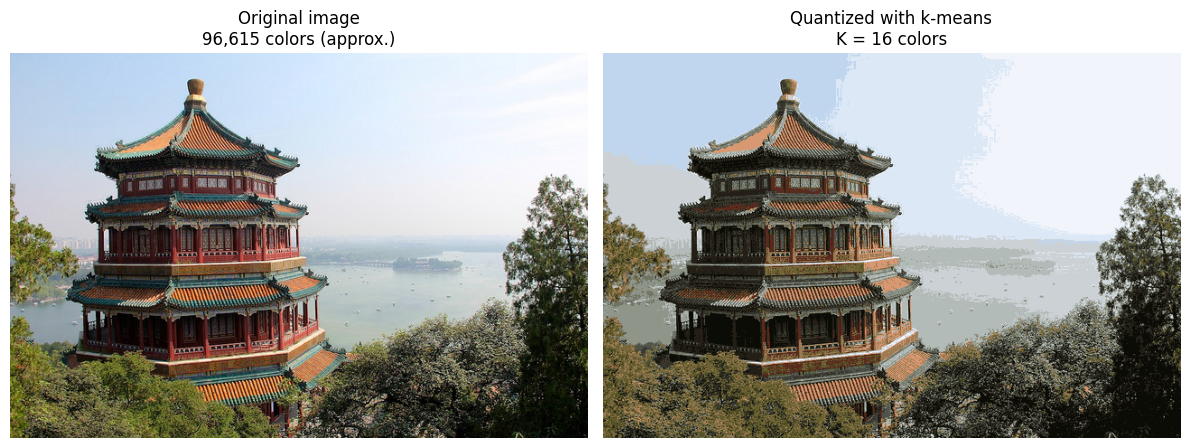

In [12]:

china = load_sample_image("china.jpg")
img = np.array(china, dtype=np.float64) / 255.0
h, w, c = img.shape
pixels = img.reshape(-1, 3)

# Fit on a random subsample for speed
rng = np.random.default_rng(7)
sample_idx = rng.choice(len(pixels), size=3000, replace=False)
sample = pixels[sample_idx]

K_colors = 16
km_img = KMeans(n_clusters=K_colors, init="k-means++", n_init=10, random_state=7)
km_img.fit(sample)

labels_img = km_img.predict(pixels)
quantized = km_img.cluster_centers_[labels_img].reshape(h, w, 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title(f"Original image\n{len(np.unique((img*255).astype(int).reshape(-1,3), axis=0)):,} colors (approx.)")
axes[0].axis("off")

axes[1].imshow(np.clip(quantized, 0, 1))
axes[1].set_title(f"Quantized with k-means\nK = {K_colors} colors")
axes[1].axis("off")

plt.tight_layout()
plt.show()



## 6. Challenge exercises

### Exercise 4
Run k-means on the blobs dataset with several random seeds.  
How much do the final centroids and inertia change?

### Solution 
They stay the same
### Exercise 5
Standardize the features before clustering and compare the result with the unscaled version.  
When does feature scaling matter?

### Exercise 6
Create an anisotropic dataset by applying a linear transformation to blob data.  
Show visually why k-means is less comfortable there.

### Solution
When the clusters are far away from each other, k-means works quite well even if their shapes are not perfectly round.

However, when the clusters are closer together, the limitation becomes visible. K-means does not really follow the shape of the cluster. It only assigns points to the nearest center, so it creates round/centroid-based regions.


In [14]:
#Exercise 4
seed_rows = []
seeds = [0, 7, 13, 42, 123]

for seed in seeds:
    km_seed = KMeans(n_clusters=3, init="k-means++", n_init=1, random_state=seed)
    labels_seed = km_seed.fit_predict(X_blobs)
    centers_sorted = km_seed.cluster_centers_[np.argsort(km_seed.cluster_centers_[:, 0])]
    seed_rows.append({
        "seed": seed,
        "inertia": km_seed.inertia_,
        "center_1": np.round(centers_sorted[0], 2),
        "center_2": np.round(centers_sorted[1], 2),
        "center_3": np.round(centers_sorted[2], 2),
    })

seed_df = pd.DataFrame(seed_rows)
seed_df

,seed,inertia,center_1,center_2,center_3
0,0,909.124624,"[-4.06, -1.12]","[0.08, 3.98]","[4.02, -0.91]"
1,7,909.124624,"[-4.06, -1.12]","[0.08, 3.98]","[4.02, -0.91]"
2,13,909.124624,"[-4.06, -1.12]","[0.08, 3.98]","[4.02, -0.91]"
3,42,909.124624,"[-4.06, -1.12]","[0.08, 3.98]","[4.02, -0.91]"
4,123,909.124624,"[-4.06, -1.12]","[0.08, 3.98]","[4.02, -0.91]"


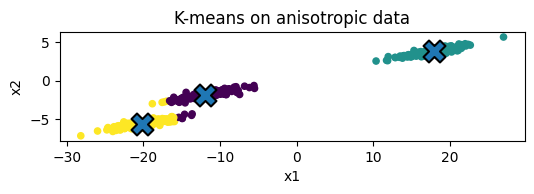

In [17]:
#Exercise 6

X_iso, _ = make_blobs(n_samples=500, centers=3, cluster_std=0.8, random_state=17)
transformation = np.array([[3.0, 0.5],
                           [0.2, 0.3]])
X_aniso = X_iso @ transformation

km_aniso = KMeans(n_clusters=3, init="k-means++", n_init=20, random_state=17)
labels_aniso = km_aniso.fit_predict(X_aniso)

fig, ax = plt.subplots()
plot_clusters(X_aniso, labels_aniso, km_aniso.cluster_centers_, title="K-means on anisotropic data", ax=ax)
ax.set_aspect("equal", adjustable="box")
plt.show()




## References

The examples in this notebook were inspired by the official scikit-learn documentation:

1. **Clustering user guide**, section on k-means  
   https://scikit-learn.org/stable/modules/clustering.html

2. **Demonstration of k-means assumptions**  
   https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_assumptions.html

3. **Selecting the number of clusters with silhouette analysis on KMeans clustering**  
   https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

4. **Color Quantization using K-Means**  
   https://scikit-learn.org/0.23/auto_examples/cluster/plot_color_quantization.html

5. **silhouette_score documentation**  
   https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html
